# COMSOL Full-Wave Simulation of a Coupled Quarter-Wave Resonator

::::{admonition} Required extras
:class: tip

This notebook needs the `comsol` extra:

```bash
uv add "qpdk[comsol]"
# or, from a checkout of this repository:
uv sync --extra comsol
# or with pip:
pip install "qpdk[comsol]"
```

Installing the extra installs `MPh`, the Python client for COMSOL, and nothing
else. **It does not install COMSOL and it does not grant a license.** Running
the model build and the full-wave solve needs a local COMSOL installation, a
license, and the RF Module. Google Colab has none of them, so the build cells
cannot run there.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

This notebook takes a QPDK coupled quarter-wave resonator all the way to a
solved COMSOL model: it prepares the ported layout, builds the sheet model
with air and silicon domains, assigns PEC and numeric TEM ports, adds a
frequency study, solves it, and reads back real field and S-parameter results.

The committed results shown at the end of the notebook come from an actual
COMSOL 6.3 solve. The build and solve cells are gated behind `RUN_COMSOL`
because they need a license; set it to `True` on a licensed machine to
reproduce them. With `RUN_COMSOL = False` it plots the committed data without
a license. The documentation build uses the saved notebook outputs.
If running a downloaded copy outside a repository checkout, place the
[sweep CSV](data/comsol_cpw_sparameters.csv)
and [field TXT](data/comsol_cpw_field.txt)
in a `data/` directory next to the notebook.
The [single-point check](data/comsol_cpw_singlepoint.csv) is also included.

## What is being modelled

The device is a QPDK
{py:func}`~qpdk.cells.quarter_wave_resonator_coupled`: a meandering
coplanar-waveguide (CPW) resonator placed alongside a straight feedline,
separated by a coupling gap. This is the standard hanger geometry used to read
out superconducting qubits {cite:p}`gopplCoplanarWaveguideResonators2008a`.

Two terminations define a **quarter-wave** resonator:

- The end nearest the feedline is **open**, where the voltage has an antinode.
- The far end is **shorted**, where the current has an antinode.

A line with one open and one shorted end resonates when its electrical length
is an odd multiple of $\lambda/4$. Close to resonance the coupling capacitor
loads the feedline and the transmission $|S_{21}|$ shows a **notch**: at the
resonant frequency, power that would travel from `coupling_o1` to
`coupling_o2` is largely reflected. The centre of the notch gives $f_r$ and
its width the loaded quality factor.

## The model behind the results

COMSOL's own RF example ["Coplanar Waveguide Resonator"](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
is the companion for this geometry. The model built here uses the same stack
and port approach:

1. A silicon block under the metal and an air region above, meeting at the
   metal plane.
2. **PEC on the metal sheets.** The metal is drawn as faces on the
   silicon/air interface rather than as a thin extruded solid, which meshes far
   more reliably for a metal that is three orders of magnitude thinner than the
   substrate.
3. **Numeric TEM ports** on two feed cross sections, each with a **voltage
   integration line** running from ground to the centre conductor.
4. **Boundary mode analysis** study steps that solve the 2D cross-section
   eigenmode and supply each port's mode field.
5. A **frequency-domain study** over the feedline's transmission band.

The outer air and silicon walls use COMSOL's default PEC boundary. This is a
finite conducting enclosure, whereas the reference includes scattering
boundaries. Its influence on the S-parameters has not been converged away.

### What PEC leaves out

The QPDK metal is a superconductor, but this first model treats it as a
perfect electric conductor. PEC has zero surface resistance, so it predicts no
conductor loss, and it ignores the **kinetic inductance** of the film. It is a
useful first approximation for checking geometry, porting, and coupling, but a
measured quality factor cannot be predicted from it. The kinetic inductance
also shifts the resonance. Replacing PEC with a surface-impedance or transition boundary condition
is the next modelling step.

### The ported layout

`prepare_comsol_layout` inverts the M1 etch mask into a ground plane, and the
ground plane then *surrounds* the source feed ports, which sit at $x = 0$ and
$x = 200$ µm inside the prepared bounding box. A port face there would be
buried in ground metal, so those planes cannot be turned into TEM ports.

To expose them, this notebook extends each feed with a straight CPW section to
a plane clear of the whole resonator, then extracts with
`crop_to_feed_ports=True` so both external faces are open CPW cross sections.
**The extension is part of the modelled device**: it lengthens the feedline and
changes the coupling geometry, so the resonance solved here is the resonance of
this extended layout and not the resonance of the unextended reference cell.

### The frequency sweep is not a resonance measurement

The committed S-parameter curve comes from a coarse sweep over 5 to 10 GHz in
steps of 0.25 GHz. A hanger resonator can reach $Q \sim 10^4$ to $10^6$, so its
fractional linewidth can be $10^{-4}$ or smaller, far narrower than the
0.25 GHz spacing. A sweep at this spacing samples the band but **cannot resolve
a notch**, and no resonance frequency or quality factor can be read off it.
Locating $f_r$ that way needs either an eigenfrequency search followed by a
narrow sweep around it, or a much finer grid, plus a mesh refined in the CPW
gaps. The results section below says exactly what the saved data does and does
not show.

**References:**
- [COMSOL "Coplanar Waveguide Resonator" model](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
- [COMSOL RF Module User's Guide](https://doc.comsol.com/6.3/doc/com.comsol.help.rf/RFModuleUsersGuide.pdf)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)
- MPh repository: https://github.com/MPh-py/MPh

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the build and solve cells below "
        "cannot run in Colab."
    )

In [2]:
from pathlib import Path

import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon as MplPolygon

from qpdk import PDK
from qpdk.cells.resonator import quarter_wave_resonator_coupled
from qpdk.config import PATH
from qpdk.simulation import (
    add_cpw_rf_study,
    build_comsol_sheet_model,
    prepare_comsol_layout,
)
from qpdk.tech import coplanar_waveguide

try:
    import mph
except ImportError:
    mph = None

PDK.activate()

MPH_AVAILABLE = mph is not None

#: Committed COMSOL results, either relative to the repository root or to a
#: working directory of `notebooks/`.
_DATA_DIR_CANDIDATES = (
    PATH.repo / "notebooks" / "data",
    Path("notebooks/data"),
    Path("data"),
)


def data_path(name: str) -> Path:
    """Return the path of a committed data file in ``notebooks/data``.

    Returns:
        The first existing candidate path.

    Raises:
        FileNotFoundError: If no candidate holds the file.
    """
    for directory in _DATA_DIR_CANDIDATES:
        candidate = directory / name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"{name!r} not found in {[str(directory) for directory in _DATA_DIR_CANDIDATES]}"
    )

## Build the ported layout

The resonator is created with an explicit CPW cross-section so that the
centre-conductor width and the gap are known constants we reuse when
describing the ports. On the source cell the feed ports `coupling_o1` and
`coupling_o2` sit at $x = 0$ and $x = 200$ µm, well inside the prepared ground
plane. Each is extended to the left and right with a straight CPW of the same
cross-section, so the new feed planes at $x = -300$ µm and $x = 900$ µm are
clear of the resonator and the ground margin.

In [3]:
CPW_WIDTH_UM = 10.0
CPW_GAP_UM = 6.0
LEFT_EXTENSION_UM = 300.0
RIGHT_EXTENSION_UM = 700.0
GROUND_MARGIN_UM = 100.0

cross_section = coplanar_waveguide(width=CPW_WIDTH_UM, gap=CPW_GAP_UM)

resonator = quarter_wave_resonator_coupled(
    length=4000.0,
    meanders=4,
    cross_section=cross_section,
    cross_section_non_resonator=cross_section,
    coupling_straight_length=200.0,
    coupling_gap=20.0,
)

component = gf.Component(name="comsol_cpw_resonator")
component << resonator

left_straight = component << gf.components.straight(
    length=LEFT_EXTENSION_UM, cross_section=cross_section
)
right_straight = component << gf.components.straight(
    length=RIGHT_EXTENSION_UM, cross_section=cross_section
)
left_straight.connect("o2", resonator.ports["coupling_o1"])
right_straight.connect("o1", resonator.ports["coupling_o2"])
component.add_port("input", port=left_straight.ports["o1"])
component.add_port("output", port=right_straight.ports["o2"])

print(f"Extended component: {component.name}")
print(f"Bounding box (µm): {component.bbox()}")
for port in component.ports:
    print(
        f"  {port.name}: center={tuple(round(value, 3) for value in port.center)} µm, "
        f"width={port.width} µm, orientation={port.orientation}°"
    )

Extended component: comsol_cpw_resonator
Bounding box (µm): (-300,-841;900,11)
  input: center=(-300.0, 0.0) µm, width=10.0 µm, orientation=180.0°
  output: center=(900.0, 0.0) µm, width=10.0 µm, orientation=0.0°


In [4]:
layout = prepare_comsol_layout(
    component,
    feed_ports=("input", "output"),
    ground_margin=GROUND_MARGIN_UM,
    crop_to_feed_ports=True,
)

hole_count = sum(len(polygon.holes) for polygon in layout.polygons)
print(f"Metal polygons: {len(layout.polygons)} ({hole_count} holes total)")
print(f"Prepared bounding box (µm): {layout.bbox}")
for feed in layout.feed_ports:
    print(
        f"Feed {feed.name}: center={feed.center} µm, width={feed.width} µm, "
        f"orientation={feed.orientation}°"
    )

Metal polygons: 3 (1 holes total)
Prepared bounding box (µm): ComsolBoundingBox(xmin=-300.0, ymin=-941.0, xmax=900.0, ymax=111.0)
Feed input: center=(-300.0, 0.0) µm, width=10.0 µm, orientation=180.0°
Feed output: center=(900.0, 0.0) µm, width=10.0 µm, orientation=0.0°


The result is three metal polygons with one hole. One polygon is the ground
plane, and the hole is the CPW channel cut through it: the centre-conductor
strip, both etch gaps, and the surrounding ground all come from that one
outline-plus-hole shape. Cropping to the feed planes cut the ground back so
each external face shows an open CPW cross section instead of a wall of
ground, which is what lets the port solver define a mode there.

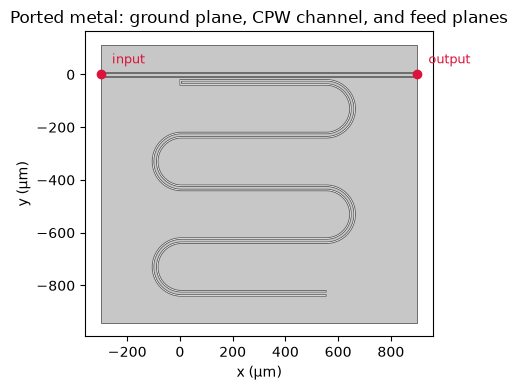

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for polygon in sorted(
    layout.polygons,
    key=lambda item: (
        -(
            (max(x for x, _ in item.outline) - min(x for x, _ in item.outline))
            * (max(y for _, y in item.outline) - min(y for _, y in item.outline))
        )
    ),
):
    ax.add_patch(
        MplPolygon(
            polygon.outline,
            closed=True,
            facecolor="0.78",
            edgecolor="0.35",
            linewidth=0.6,
            zorder=1,
        )
    )
    for hole in polygon.holes:
        ax.add_patch(
            MplPolygon(
                hole,
                closed=True,
                facecolor="white",
                edgecolor="0.35",
                linewidth=0.6,
                zorder=1,
            )
        )
for feed in layout.feed_ports:
    ax.plot(*feed.center, marker="o", color="crimson", markersize=6, zorder=4)
    ax.annotate(
        feed.name,
        feed.center,
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
        color="crimson",
    )
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Ported metal: ground plane, CPW channel, and feed planes")
plt.tight_layout()
plt.show()

## Build the COMSOL model, physics, and study

Three calls turn the layout into a configured model:

- {py:func}`~qpdk.simulation.comsol_sheet.build_comsol_sheet_model` creates the
  air and silicon blocks meeting at $z = 0$, imprints the layout metal on that
  interface as faces, and assigns materials ($\epsilon_r = 1$ air,
  $\epsilon_r = 11.7$ silicon).
- {py:func}`~qpdk.simulation.comsol_rf.add_cpw_rf_study` selects the metal
  faces and applies PEC, adds two numeric TEM ports with voltage integration
  lines spanning the CPW gap, adds the mesh sequence, and adds a study with one
  boundary mode analysis step per port plus a frequency step. Every selection
  is derived from the layout geometry, so no face or edge ID is hard-coded.
- The last calls set the sweep and run it.

The boundary mode steps use 5 GHz as their reference and search near an
effective mode index of 2.5, following the COMSOL CPW reference. The port
mode is then used across the frequency sweep. Check passivity before using
a sweep for design decisions: a passive two-port should have
$|S_{11}|^2 + |S_{21}|^2 \leq 1$ within numerical tolerance.

`mph.start(cores=...)` launches a COMSOL server process and attaches to it.
Only one MPh client can exist per Python process, and the call needs a COMSOL
installation and a license. The whole block is off by default so the notebook
runs without one; set `RUN_COMSOL = True` on a licensed machine to build, solve,
and save the model.

In [6]:
RUN_COMSOL = False
MODEL_DIR = Path.home() / "comsol_models"
MODEL_PATH = MODEL_DIR / "comsol_cpw_resonator.mph"
CORES = 4
SOLVE_FREQUENCY_GHZ = 7.5
SAVED_FIELD_FREQUENCY_GHZ = 7.5
MODE_FREQUENCY_GHZ = 5.0
SWEEP_EXPRESSION = "range(5[GHz],0.25[GHz],10[GHz])"

model = None
if RUN_COMSOL and not MPH_AVAILABLE:
    raise RuntimeError("RUN_COMSOL needs MPh and a licensed COMSOL installation")

if RUN_COMSOL and MPH_AVAILABLE:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    client = mph.start(cores=CORES)
    model = build_comsol_sheet_model(
        client,
        layout,
        name="QPDK Coupled Quarter-Wave Resonator",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    add_cpw_rf_study(
        model,
        layout,
        cpw_gap_um=CPW_GAP_UM,
        frequency_ghz=MODE_FREQUENCY_GHZ,
        mesh_size=8,
    )
    model.java.study("std1").feature("freq").set("plist", SWEEP_EXPRESSION)
    model.java.component("comp1").mesh("mesh1").run()
    model.java.study("std1").run()
    model.save(MODEL_PATH)

    solved_frequencies_ghz = np.atleast_1d(model.evaluate("freq")) / 1e9
    solved_s21_db = np.atleast_1d(model.evaluate("emw.S21dB"))
    solved_s11_db = np.atleast_1d(model.evaluate("emw.S11dB"))
    solved_power_sum = 10 ** (solved_s21_db / 10) + 10 ** (solved_s11_db / 10)
    if solved_power_sum.max() > 1.001:
        raise ValueError("The solved sweep violates passive two-port power balance")
    print(f"Solved {solved_frequencies_ghz.size} frequency points")
    print(f"Saved model to {MODEL_PATH}")

    sweep_path = MODEL_DIR / "comsol_cpw_sparameters.csv"
    np.savetxt(
        sweep_path,
        np.column_stack([solved_frequencies_ghz, solved_s21_db, solved_s11_db]),
        delimiter=",",
        header="frequency_ghz,s21_db,s11_db",
        comments="",
    )
    print(f"Saved sweep to {sweep_path}")

    nearest = int(np.argmin(np.abs(solved_frequencies_ghz - SOLVE_FREQUENCY_GHZ)))
    print(
        f"At {solved_frequencies_ghz[nearest]:.2f} GHz: "
        f"S21 = {solved_s21_db[nearest]:+.3f} dB, "
        f"S11 = {solved_s11_db[nearest]:+.3f} dB"
    )

A single-point solve is a quick check of the ports. Set the frequency step's
`plist` to one value (`"7.5[GHz]"`) and compare it with the corresponding
sweep point. The independent solve supplied with this notebook used the same
layout, 5 GHz boundary-mode reference, and mesh-size setting. It returned
$S_{21}=-0.2511$ dB and $S_{11}=-12.5106$ dB at 7.5 GHz, whereas the sweep
returned $-0.1786$ dB and $-13.9515$ dB. A separate run with the sweep's
frequency range in place during meshing gave the same single-point values.
The cause has not been isolated, so this curve is a solver workflow example,
not a converged response to use for design decisions. Investigate study,
solver, port-mode, and mesh settings before interpreting a resonant feature.

### Exporting a field map

The committed field data in `notebooks/data/comsol_cpw_field.txt` was written
from the solved model with COMSOL's Data export on a cut plane at $z = 1$ µm,
exported at 7.5 GHz. The same export is scripted below: a
`CutPlane` dataset over the $xy$ plane, then a `Data` result export with the
expression `emw.normE`. It runs inside the licensed branch, next to the solve,
and writes a file of the same shape as the committed one.

In [7]:
if RUN_COMSOL and MPH_AVAILABLE and model is not None:
    plane = model.java.result().dataset().create("cutplane", "CutPlane")
    plane.set("planetype", "quick")
    plane.set("quickplane", "xy")
    plane.set("quickz", "1[um]")
    plane.set("data", "dset1")

    field_export = model.java.result().export().create("field", "Data")
    field_export.set("data", "cutplane")
    field_export.set("expr", ["emw.normE"])
    field_export.set("innerinput", "manual")
    field_export.set("solnum", str(nearest + 1))
    field_export.set("filename", str(MODEL_DIR / "comsol_cpw_field.txt"))
    field_export.run()
    print(f"Exported emw.normE to {MODEL_DIR / 'comsol_cpw_field.txt'}")

## Saved transmission sweep

The committed curve was produced by the sweep configured above and exported as
`frequency_ghz, s21_db, s11_db`. It is a transmission snapshot of the ported
feedline, not a resonance measurement: the sweep spacing is much wider than the
expected linewidth, so the curve is smooth wherever the resonance actually sits
and no notch is resolved. The values are real solver output at each sweep
point; what they do not establish is $f_r$ or $Q$.

In [8]:
results_dir = MODEL_DIR if RUN_COMSOL else None
sweep_file = (
    results_dir / "comsol_cpw_sparameters.csv"
    if results_dir is not None
    else data_path("comsol_cpw_sparameters.csv")
)
SPARAMETERS = np.atleast_1d(np.genfromtxt(sweep_file, delimiter=",", names=True))
sweep_ghz = SPARAMETERS["frequency_ghz"]
sweep_s21_db = SPARAMETERS["s21_db"]
sweep_s11_db = SPARAMETERS["s11_db"]
power_sum = 10 ** (sweep_s21_db / 10) + 10 ** (sweep_s11_db / 10)
if power_sum.max() > 1.001:
    raise ValueError("The saved sweep violates passive two-port power balance")

nearest = int(np.argmin(np.abs(sweep_ghz - SOLVE_FREQUENCY_GHZ)))
print(
    f"Sweep points: {sweep_ghz.size}, {sweep_ghz.min():.2f} to {sweep_ghz.max():.2f} GHz"
)
print(
    f"At {sweep_ghz[nearest]:.2f} GHz: "
    f"S21 = {sweep_s21_db[nearest]:+.3f} dB, "
    f"S11 = {sweep_s11_db[nearest]:+.3f} dB"
)
print(
    "Scan of the band: "
    f"S21 from {sweep_s21_db.min():+.3f} to {sweep_s21_db.max():+.3f} dB, "
    f"S11 from {sweep_s11_db.min():+.3f} to {sweep_s11_db.max():+.3f} dB"
)
print(f"Largest |S11|² + |S21|² = {power_sum.max():.6f}")
if not RUN_COMSOL:
    single_point = np.genfromtxt(
        data_path("comsol_cpw_singlepoint.csv"), delimiter=",", names=True
    )
    print(
        "Independent single point at 7.5 GHz: "
        f"S21 = {single_point['s21_db']:+.3f} dB, "
        f"S11 = {single_point['s11_db']:+.3f} dB"
    )

Sweep points: 21, 5.00 to 10.00 GHz
At 7.50 GHz: S21 = -0.179 dB, S11 = -13.951 dB
Scan of the band: S21 from -0.294 to -0.084 dB, S11 from -17.191 to -11.836 dB
Largest |S11|² + |S21|² = 1.000039
Independent single point at 7.5 GHz: S21 = -0.251 dB, S11 = -12.511 dB


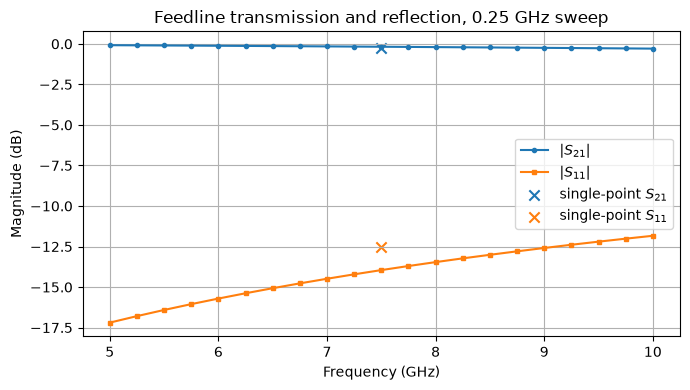

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep_ghz, sweep_s21_db, marker="o", markersize=3, label=r"$|S_{21}|$")
ax.plot(sweep_ghz, sweep_s11_db, marker="s", markersize=3, label=r"$|S_{11}|$")
if not RUN_COMSOL:
    ax.scatter(
        single_point["frequency_ghz"],
        single_point["s21_db"],
        marker="x",
        color="C0",
        s=55,
        label="single-point $S_{21}$",
    )
    ax.scatter(
        single_point["frequency_ghz"],
        single_point["s11_db"],
        marker="x",
        color="C1",
        s=55,
        label="single-point $S_{11}$",
    )
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Feedline transmission and reflection, 0.25 GHz sweep")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

The curve varies smoothly by a fraction of a dB across the band. That is the
expected response of a feedline sampled far from any narrow feature; it is not
evidence that the resonator has no resonance, only that this grid cannot see
one. Two things resolve it: an eigenfrequency search to place $f_r$, then a
narrow frequency sweep of a few linewidths around that value with the adaptive
sweep enabled; and a mesh refined in the CPW gaps so the notch depth and
position stop moving under refinement.

## Saved field map

The exported field is the electric-field norm on the $z = 1$ µm plane at the
saved 7.5 GHz point. The metal sheet lies at $z = 0$ and the plane sits just above
it, so the map shows the modal field in the CPW gaps and along the resonator.

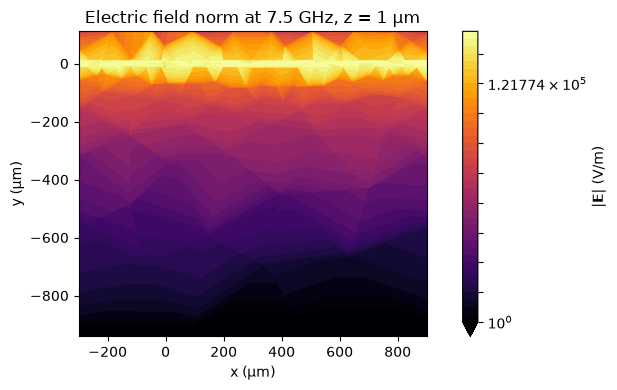

In [10]:
field_file = (
    results_dir / "comsol_cpw_field.txt"
    if results_dir is not None
    else data_path("comsol_cpw_field.txt")
)
field = np.loadtxt(field_file, comments="%")
field_x, field_y, field_e = field[:, 0], field[:, 1], field[:, 3]

fig, ax = plt.subplots(figsize=(8, 4))
contour = ax.tricontourf(
    field_x,
    field_y,
    field_e,
    levels=np.geomspace(1.0, field_e.max(), 40),
    norm=LogNorm(vmin=1.0, vmax=field_e.max()),
    cmap="inferno",
    extend="min",
)
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
field_frequency_ghz = sweep_ghz[nearest] if RUN_COMSOL else SAVED_FIELD_FREQUENCY_GHZ
ax.set_title(f"Electric field norm at {field_frequency_ghz:g} GHz, z = 1 µm")
fig.colorbar(contour, ax=ax, label=r"$|\mathbf{E}|$ (V/m)")
plt.tight_layout()
plt.show()

The field concentrates in the narrow CPW gaps and at the ends of the metal
edges, where the surface charge collects. That localisation is why the mesh has
to be refined in the gaps before the notch position is trusted: an
under-resolved gap smears the field and shifts the resonance.

## Summary

1. Built a coupled quarter-wave resonator, extended both feeds with straight
   CPW to planes clear of the resonator, and extracted a ported layout with
   `crop_to_feed_ports=True`, so both external faces are open CPW cross
   sections. The extension is part of the modelled device and changes the
   coupling geometry relative to the unextended cell.
2. Built the COMSOL sheet model (air, silicon, metal faces on the interface)
   and configured the PEC, the two numeric TEM ports with voltage integration
   lines, the mesh, and the frequency study, all from layout geometry.
3. Solved a 5 to 10 GHz sweep and read back `emw.S21dB`, `emw.S11dB`, and the
   electric field norm.
4. Showed the committed sweep and field map, and stated what they do not show:
   the 0.25 GHz spacing is far wider than the expected linewidth, so no
   resonance frequency or quality factor is read off this curve.

### Limitations

- Metal is PEC: no surface resistance and no kinetic inductance, so loss and
  the kinetic-inductance frequency shift are both missing.
- The sweep is sparse and the mesh is a single automatic setting; neither is a
  convergence study.
- The feed extension is not the reference device, so the solved coupling is
  not the reference coupling.

### Next steps

- Add an eigenfrequency study to locate $f_r$, then sweep a few linewidths
  around it with the adaptive sweep enabled.
- Refine the mesh in the CPW gaps and confirm $f_r$ and the notch depth stop
  moving.
- Replace PEC with a surface-impedance or transition boundary condition using
  the superconductor's surface resistance and kinetic inductance to get a
  realistic $Q$.
- Compare the ported section against the QPDK analytical and SAX models in
  {doc}`/notebooks/all_models` as a sanity check on the coupling.

## References

```{bibliography}
:filter: docname in docnames
```